In [34]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---------- 全局随机种子：只改 RANDOM_STATE，下面 train_test_split / sklearn / XGB 均引用它 ----------
RANDOM_STATE = 2
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# 原始未编码数据（请将工作目录设为 final_model，或与本 notebook 同文件夹）
df = pd.read_csv("Obesity_data_clean.csv")
print("Dataset shape:", df.shape)
print(df.head())
df.info()


Dataset shape: (2087, 17)
   gender   age  height  weight family_history high_cal_food  veg_consumption  \
0  Female  21.0    1.62    64.0            yes            no              2.0   
1  Female  21.0    1.52    56.0            yes            no              3.0   
2    Male  23.0    1.80    77.0            yes            no              2.0   
3    Male  27.0    1.80    87.0             no            no              3.0   
4    Male  22.0    1.78    89.8             no            no              2.0   

   meals_per_day   snacking smoking  water_intake calorie_monitor  \
0            3.0  Sometimes      no           2.0              no   
1            3.0  Sometimes     yes           3.0             yes   
2            3.0  Sometimes      no           2.0              no   
3            3.0  Sometimes      no           2.0              no   
4            1.0  Sometimes      no           2.0              no   

   physical_activity  screen_time     alcohol              transport  \


obesity_level
Insufficient_Weight    267
Normal_Weight          282
Overweight_Level_I     276
Overweight_Level_II    290
Obesity_Type_I         351
Obesity_Type_II        297
Obesity_Type_III       324
Name: count, dtype: int64


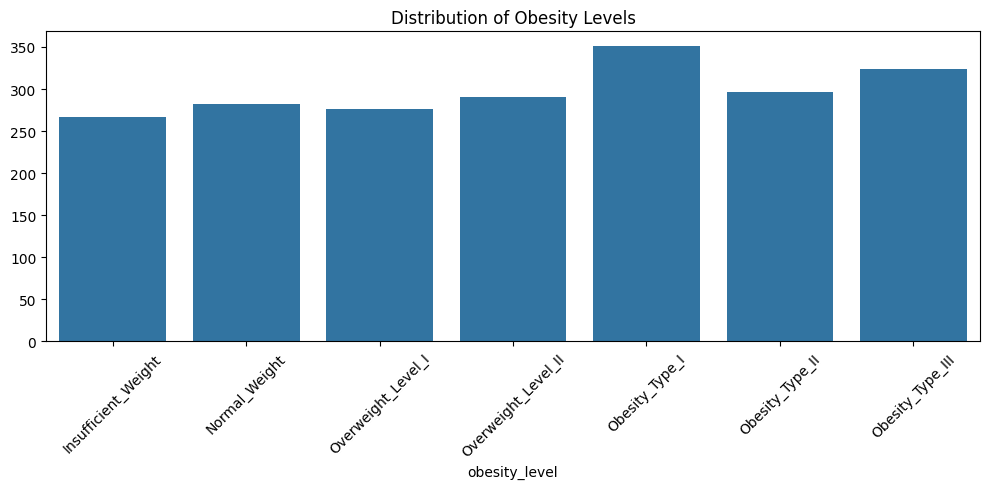

In [35]:
# 目标变量：肥胖等级 obesity_level（七分类）
severity_order = [
    'Insufficient_Weight',
    'Normal_Weight',
    'Overweight_Level_I',
    'Overweight_Level_II',
    'Obesity_Type_I',
    'Obesity_Type_II',
    'Obesity_Type_III'
]
df['obesity_level'] = pd.Categorical(df['obesity_level'], categories=severity_order, ordered=True)

counts = df['obesity_level'].value_counts(sort=False)
print(counts)
plt.figure(figsize=(10, 5))
sns.barplot(x=counts.index.astype(str), y=counts.values)
plt.xticks(rotation=45)
plt.title('Distribution of Obesity Levels')
plt.tight_layout()
plt.show()


In [36]:
# ---------- 特征方案（二选一）：只保留一种 DROP_COLS 赋值，其余用 # 注释 ----------
# 不以 BMI 为特征（本 CSV 无 BMI 列）；人口学里 gender/height/weight/family_history 始终排除

# 方案 A：仅生活习惯（同时排除 age）
# DROP_COLS = ["gender", "age", "height", "weight", "family_history", "obesity_level"]

# 方案 B：生活习惯 + age（当前默认）
DROP_COLS = ["gender", "height", "weight", "family_history", "obesity_level"]
X_raw = df.drop(columns=[c for c in DROP_COLS if c in df.columns])
y = df["obesity_level"]

print("Feature columns:", list(X_raw.columns))
print("Features shape (raw):", X_raw.shape)
print("Target shape:", y.shape)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)


Feature columns: ['age', 'high_cal_food', 'veg_consumption', 'meals_per_day', 'snacking', 'smoking', 'water_intake', 'calorie_monitor', 'physical_activity', 'screen_time', 'alcohol', 'transport']
Features shape (raw): (2087, 12)
Target shape: (2087,)
Training set size: (1669, 12)
Test set size: (418, 12)


In [37]:
def transform_obesity_features(X: pd.DataFrame) -> pd.DataFrame:
    """统一编码：二值 0/1；有序频率/程度 → 有序整数；名义 transport → one-hot。
    CSV 中部分序数列为浮点噪声，四舍五入后 clip 到合理整数区间。"""
    out = pd.DataFrame(index=X.index)
    if "age" in X.columns:
        out["age"] = pd.to_numeric(X["age"], errors="coerce")

    def bin_yes_no(s: pd.Series) -> pd.Series:
        return s.astype(str).str.lower().map({"yes": 1, "no": 0})

    out["high_cal_food"] = bin_yes_no(X["high_cal_food"])
    out["smoking"] = bin_yes_no(X["smoking"])
    out["calorie_monitor"] = bin_yes_no(X["calorie_monitor"])

    freq_order = ["no", "Sometimes", "Frequently", "Always"]
    fo = {k: i for i, k in enumerate(freq_order)}
    out["snacking"] = X["snacking"].map(fo)
    out["alcohol"] = X["alcohol"].map(fo)

    out["veg_consumption"] = X["veg_consumption"].round().clip(1, 3).astype(int)
    out["meals_per_day"] = X["meals_per_day"].round().clip(1, 4).astype(int)
    out["water_intake"] = X["water_intake"].round().clip(1, 3).astype(int)
    out["physical_activity"] = X["physical_activity"].round().clip(0, 3).astype(int)
    out["screen_time"] = X["screen_time"].round().clip(0, 2).astype(int)

    transport_dum = pd.get_dummies(X["transport"], prefix="transport", dtype=int)
    out = pd.concat([out, transport_dum], axis=1)
    return out


X_train = transform_obesity_features(X_train)
X_test = transform_obesity_features(X_test)
# 测试集若缺某交通方式列，对齐训练列
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print("Encoded feature shape:", X_train.shape)
print(X_train.head())


Encoded feature shape: (1669, 16)
            age  high_cal_food  smoking  calorie_monitor  snacking  alcohol  \
1027  21.027662              1        0                0         1        1   
909   22.814657              1        0                0         1        1   
636   20.744839              1        0                0         2        0   
919   24.284861              1        0                0         1        0   
1304  30.967417              1        0                0         1        1   

      veg_consumption  meals_per_day  water_intake  physical_activity  \
1027                2              3             2                  2   
909                 2              3             2                  0   
636                 3              3             2                  2   
919                 2              3             2                  1   
1304                2              3             3                  1   

      screen_time  transport_Automobile  transport_B

In [38]:
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)

# 主指标：macro；同时报告 weighted


def print_classification_metrics(model_name: str, y_true, y_pred) -> None:
    acc = accuracy_score(y_true, y_pred)
    f1_mac = f1_score(y_true, y_pred, average="macro", zero_division=0)
    f1_w = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    p_mac = precision_score(y_true, y_pred, average="macro", zero_division=0)
    p_w = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    r_mac = recall_score(y_true, y_pred, average="macro", zero_division=0)
    r_w = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    print(f"--- {model_name} ---")
    print(f"  Accuracy:           {acc:.4f}")
    print(f"  F1 (macro) [主]:   {f1_mac:.4f}")
    print(f"  F1 (weighted):     {f1_w:.4f}")
    print(f"  Precision (macro): {p_mac:.4f}")
    print(f"  Precision (weighted): {p_w:.4f}")
    print(f"  Recall (macro):    {r_mac:.4f}")
    print(f"  Recall (weighted): {r_w:.4f}")


In [39]:
# ========== 原 model_O（对比用）：Pipeline + StandardScaler + class_weight='balanced' ==========
# from sklearn.linear_model import LogisticRegression
# from sklearn.model_selection import GridSearchCV
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import StandardScaler
#
# param_grid = {
#     "clf__C": [0.01, 0.1, 1, 10, 100],
#     "clf__penalty": ["l2"],
#     "clf__solver": ["lbfgs", "newton-cg"],
# }
# pipe_lr = Pipeline(
#     [
#         ("scaler", StandardScaler()),
#         ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE, class_weight="balanced")),
#     ]
# )
# grid_lr = GridSearchCV(pipe_lr, param_grid, cv=5, scoring="f1_macro", n_jobs=1)
# grid_lr.fit(X_train, y_train)
# best_lr = grid_lr.best_estimator_
# y_pred_lr = best_lr.predict(X_test)
# print_classification_metrics("Logistic Regression", y_test, y_pred_lr)
# print("Best params:", grid_lr.best_params_)

# ========== 与 1.ipynb 参数一致：仍用 Pipeline(StandardScaler→LR)，仅去掉 class_weight；网格 clf__* 不变 ==========
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

param_grid = {
    "clf__C": [0.01, 0.1, 1, 10, 100],
    "clf__penalty": ["l2"],
    "clf__solver": ["lbfgs", "newton-cg"],
}
pipe_lr = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ]
)
grid_lr = GridSearchCV(pipe_lr, param_grid, cv=5, scoring="f1_macro", n_jobs=1)
grid_lr.fit(X_train, y_train)
best_lr = grid_lr.best_estimator_
y_pred_lr = best_lr.predict(X_test)
print_classification_metrics("Logistic Regression", y_test, y_pred_lr)
print("Best params:", grid_lr.best_params_)



--- Logistic Regression ---
  Accuracy:           0.5000
  F1 (macro) [主]:   0.4617
  F1 (weighted):     0.4714
  Precision (macro): 0.4783
  Precision (weighted): 0.4827
  Recall (macro):    0.4845
  Recall (weighted): 0.5000
Best params: {'clf__C': 1, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}


In [40]:
# ========== 原 model_O：GridSearchCV scoring=f1_macro ==========
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.model_selection import GridSearchCV
#
# dt = DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE)
# param_grid = {
#     "max_depth": [12, 15, 18, 20, None],
#     "min_samples_split": [2, 3, 4, 5],
#     "min_samples_leaf": [1, 2, 3, 4],
# }
# grid_dt = GridSearchCV(dt, param_grid, cv=5, scoring="f1_macro", n_jobs=1)
# grid_dt.fit(X_train, y_train)
# best_dt = grid_dt.best_estimator_
# y_pred_dt = best_dt.predict(X_test)
# print_classification_metrics("Decision Tree", y_test, y_pred_dt)
# print("Best params:", grid_dt.best_params_)

# ========== 与 1.ipynb 一致：参数相同，scoring=f1_weighted ==========
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

dt = DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE)
param_grid = {
    "max_depth": [12, 15, 18, 20, None],
    "min_samples_split": [2, 3, 4, 5],
    "min_samples_leaf": [1, 2, 3, 4],
}
grid_dt = GridSearchCV(dt, param_grid, cv=5, scoring="f1_weighted", n_jobs=1)
grid_dt.fit(X_train, y_train)
best_dt = grid_dt.best_estimator_
y_pred_dt = best_dt.predict(X_test)
print_classification_metrics("Decision Tree", y_test, y_pred_dt)
print("Best params:", grid_dt.best_params_)


--- Decision Tree ---
  Accuracy:           0.6651
  F1 (macro) [主]:   0.6613
  F1 (weighted):     0.6665
  Precision (macro): 0.6630
  Precision (weighted): 0.6688
  Recall (macro):    0.6606
  Recall (weighted): 0.6651
Best params: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [41]:
# ========== 原 model_O：class_weight=balanced + scoring=f1_macro ==========
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.model_selection import GridSearchCV
#
# rf = RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE)
# param_grid = {
#     "n_estimators": [100, 200],
#     "max_depth": [10, 15, 20],
# }
# grid_rf = GridSearchCV(rf, param_grid, cv=5, scoring="f1_macro", n_jobs=1)
# grid_rf.fit(X_train, y_train)
# best_rf = grid_rf.best_estimator_
# y_pred_rf = best_rf.predict(X_test)
# print_classification_metrics("Random Forest", y_test, y_pred_rf)
# print("Best params:", grid_rf.best_params_)

# ========== 与 1.ipynb 一致：无 class_weight；scoring=f1_weighted；其余网格相同 ==========
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 15, 20],
}
rf = RandomForestClassifier(random_state=RANDOM_STATE)
grid_rf = GridSearchCV(rf, param_grid, cv=5, scoring="f1_weighted", n_jobs=1)
grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)
print_classification_metrics("Random Forest", y_test, y_pred_rf)
print("Best params:", grid_rf.best_params_)


--- Random Forest ---
  Accuracy:           0.7560
  F1 (macro) [主]:   0.7477
  F1 (weighted):     0.7516
  Precision (macro): 0.7511
  Precision (weighted): 0.7535
  Recall (macro):    0.7510
  Recall (weighted): 0.7560
Best params: {'max_depth': 15, 'n_estimators': 200}


In [42]:
# ========== 旧：与 1.ipynb 一致，无网格，默认超参直接 fit ==========
# from xgboost import XGBClassifier
# y_train_xgb = y_train.cat.codes
# y_test_xgb = y_test.cat.codes
# xgb_model = XGBClassifier(
#     random_state=RANDOM_STATE,
#     eval_metric="mlogloss",
#     use_label_encoder=False,
#     n_jobs=1,
# )
# xgb_model.fit(X_train, y_train_xgb)
# y_pred_xgb = xgb_model.predict(X_test)
# print_classification_metrics("XGBoost", y_test_xgb, y_pred_xgb)

# ========== 与决策树 / 随机森林一致：简单 GridSearchCV（f1_weighted）==========
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

y_train_xgb = y_train.cat.codes
y_test_xgb = y_test.cat.codes

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.05, 0.1],
}
xgb_base = XGBClassifier(
    random_state=RANDOM_STATE,
    eval_metric="mlogloss",
    use_label_encoder=False,
    n_jobs=1,
)
grid_xgb = GridSearchCV(
    xgb_base, param_grid, cv=5, scoring="f1_weighted", n_jobs=1
)
grid_xgb.fit(X_train, y_train_xgb)
xgb_model = grid_xgb.best_estimator_
y_pred_xgb = xgb_model.predict(X_test)
print_classification_metrics("XGBoost", y_test_xgb, y_pred_xgb)
print("Best params:", grid_xgb.best_params_)


--- XGBoost ---
  Accuracy:           0.7632
  F1 (macro) [主]:   0.7574
  F1 (weighted):     0.7615
  Precision (macro): 0.7628
  Precision (weighted): 0.7644
  Recall (macro):    0.7563
  Recall (weighted): 0.7632
Best params: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200}


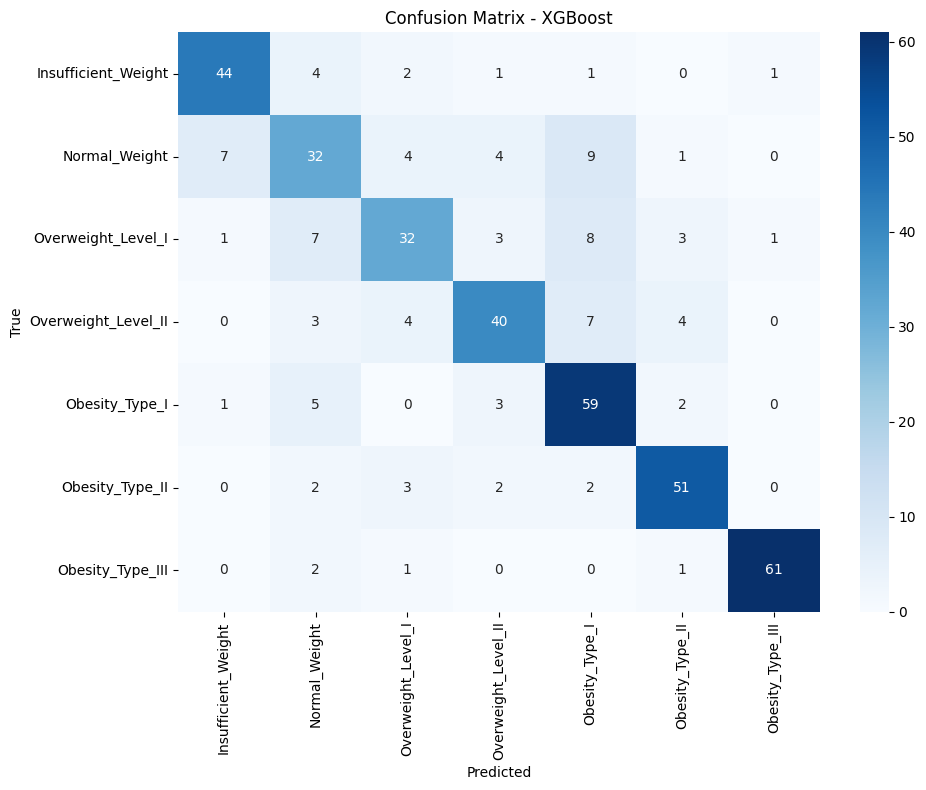

\nClassification Report (XGBoost):
                     precision    recall  f1-score   support

Insufficient_Weight       0.83      0.83      0.83        53
      Normal_Weight       0.58      0.56      0.57        57
 Overweight_Level_I       0.70      0.58      0.63        55
Overweight_Level_II       0.75      0.69      0.72        58
     Obesity_Type_I       0.69      0.84      0.76        70
    Obesity_Type_II       0.82      0.85      0.84        60
   Obesity_Type_III       0.97      0.94      0.95        65

           accuracy                           0.76       418
          macro avg       0.76      0.76      0.76       418
       weighted avg       0.76      0.76      0.76       418



In [43]:
from sklearn.metrics import classification_report, confusion_matrix

cm = confusion_matrix(y_test_xgb, y_pred_xgb)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=severity_order, yticklabels=severity_order)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - XGBoost")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300)
plt.show()

print("\\nClassification Report (XGBoost):")
print(classification_report(y_test_xgb, y_pred_xgb, target_names=severity_order, zero_division=0))


Top 10 important features:
snacking                           0.124864
veg_consumption                    0.106780
transport_Public_Transportation    0.106090
transport_Automobile               0.086713
alcohol                            0.077990
calorie_monitor                    0.068998
high_cal_food                      0.067250
meals_per_day                      0.065496
transport_Walking                  0.059257
age                                0.054595
dtype: float32


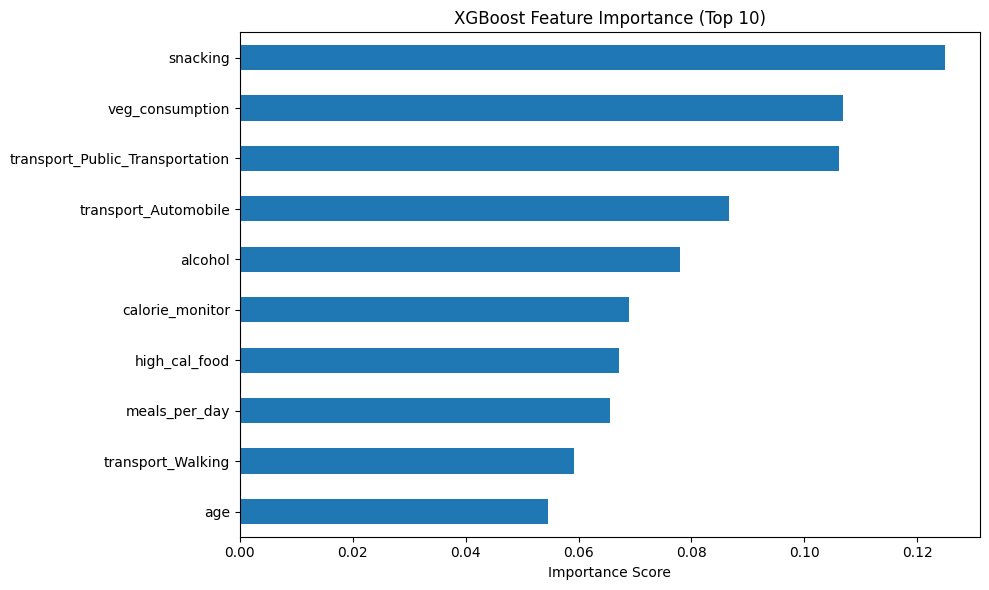

In [44]:
# ---------- 特征重要性图：合并 transport one-hot / 旧版分列 ----------
# 方式 A（推荐）：改下面这一行 —— True=合并为一项「transport」（各 dummy 列取平均）；False=旧版（每列单独，多条 transport_*）。
MERGE_TRANSPORT_IMPORTANCE = True

# 方式 B（纯注释切换）：把 MERGE_TRANSPORT_IMPORTANCE 设为 True 且下面 if/else 整块
# 换成两段二选一 —— 启用「新版」两行并注释「旧版」一行，或反过来：
#   新版: feat_imp_plot = merge_transport_onehot_importance(feat_imp)
#   旧版: feat_imp_plot = feat_imp.sort_values(ascending=False)
# 若不需要 from model_O import ...，可删掉 import，把 merge_transport_onehot_importance 函数粘到本格上方。

from model_O import merge_transport_onehot_importance

feat_imp = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
if MERGE_TRANSPORT_IMPORTANCE:
    feat_imp_plot = merge_transport_onehot_importance(feat_imp)
    print("Top 10 (transport_* → 合并为 transport，各列平均):")
else:
    feat_imp_plot = feat_imp.sort_values(ascending=False)
    print("Top 10 (旧版：每列单独，含多条 transport_*):")

print(feat_imp_plot.head(10))
plt.figure(figsize=(10, 6))
feat_imp_plot.head(10).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("XGBoost Feature Importance (Top 10)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("feature_importance_xgboost.png", dpi=300)
plt.show()
